# 🛰️ Farm Subsidy Compliance: Land Use Verification from Satellite Imagery

## Problem
Under the EU's Common Agricultural Policy (CAP), farmers receive annual
subsidies based on the land use type they declare (e.g., "cropland").
However, some parcels are later converted to unauthorized uses —
industrial development, abandonment, residential expansion — while still
being declared and subsidized as farmland. Detecting this via manual
field inspections is slow and expensive at scale.

## Solution
This project uses a deep learning model trained on ESA's Sentinel-2
satellite imagery to automatically predict the **actual** land use type
of a parcel. When the declared type doesn't match the model's prediction,
the parcel is flagged for priority field inspection.

## Data
- **Source:** EuroSAT (Sentinel-2 satellite imagery, ESA)
- **10 land use classes:** Cropland (2 types), Forest, Pasture,
  Industrial, Residential, River, Lake, Highway, Herbaceous vegetation
- **27,000 labeled images**

## Method
Convolutional Neural Network (CNN) for image classification, followed by
a "declared vs. actual" mismatch analysis to simulate a compliance
screening pipeline.

In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 2: Downloading the Satellite Imagery Dataset

Before we can train a model, we need the actual satellite images. We're
using **EuroSAT**, a public dataset built from real Sentinel-2 satellite
imagery (the same satellite constellation used operationally for EU land
monitoring), containing 27,000 labeled image tiles across 10 land cover
classes.

**What this code does, step by step:**

1. **Downloads the dataset** directly from its source server as a ZIP
   file, using the `requests` library. We manually stream the download in
   chunks to handle the file size efficiently, and we disable strict SSL
   certificate verification (`verify=False`) since this is a known
   compatibility issue with Colab's environment and a trusted public
   research dataset — not a concern with untrusted or sensitive data.
   
2. **Extracts the ZIP file** into a local folder (`./eurosat_data`),
   which unpacks into subfolders — one folder per land cover class
   (e.g., `Forest/`, `Industrial/`, `River/`), each containing hundreds
   of `.jpg` satellite tiles belonging to that class.

3. **Locates the correct folder** automatically by scanning the extracted
   contents for the directory that contains exactly 10 subfolders (our
   10 classes) — this makes the code robust even if the ZIP structure
   changes slightly.

4. **Confirms success** by printing the folder path and the list of class
   names found, which should match: `AnnualCrop`, `Forest`,
   `HerbaceousVegetation`, `Highway`, `Industrial`, `Pasture`,
   `PermanentCrop`, `Residential`, `River`, `SeaLake`.

This step mirrors loading a CSV file in a tabular ML project — except
instead of rows and columns, our "dataset" is a folder structure where
the folder name *is* the label.

In [9]:
import requests
import zipfile
import os
import pathlib
import urllib3

# Suppress the SSL warning since we're intentionally disabling verification
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

dataset_url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
zip_path = "EuroSAT.zip"

if not os.path.exists(zip_path):
    print("Downloading...")
    response = requests.get(dataset_url, verify=False, stream=True)
    response.raise_for_status()  # will error clearly if the server itself rejects the request
    with open(zip_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Download complete.")
else:
    print("Zip already downloaded.")

# Extract
extract_dir = "./eurosat_data"
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")

# Find the actual folder containing class subfolders
for root, dirs, files in os.walk(extract_dir):
    if len(dirs) == 10:  # our 10 land cover classes
        data_dir = pathlib.Path(root)
        break

print("Data directory:", data_dir)
print("Classes found:", sorted(os.listdir(data_dir)))

Downloading...
Download complete.
Extraction complete.
Data directory: eurosat_data/2750
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


We have a folder with 10 subfolders (one per land class). Now we need to load those images into memory, resize them consistently, batch them (for efficiency), and split 80/20 into train/validation — like train_test_split did for your car price data, but for image files instead of table rows.
Keras's image_dataset_from_directory does all of this in one call, and automatically uses each subfolder's name as the label — no manual labeling needed.

In [11]:
img_size = (64, 64)
batch_size = 32

ds_train = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

ds_test = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = ds_train.class_names
print("Class names:", class_names)

Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Looks clean with 21,600 training / 5,400 validation, all 10 classes present. Let's visualize a few samples.
Quick idea: we can't just trust that the loading worked — we should actually see a few images with their labels to sanity-check everything lines up correctly. This is also the first "shareable" visual for your portfolio: a grid of real satellite tiles with labels.

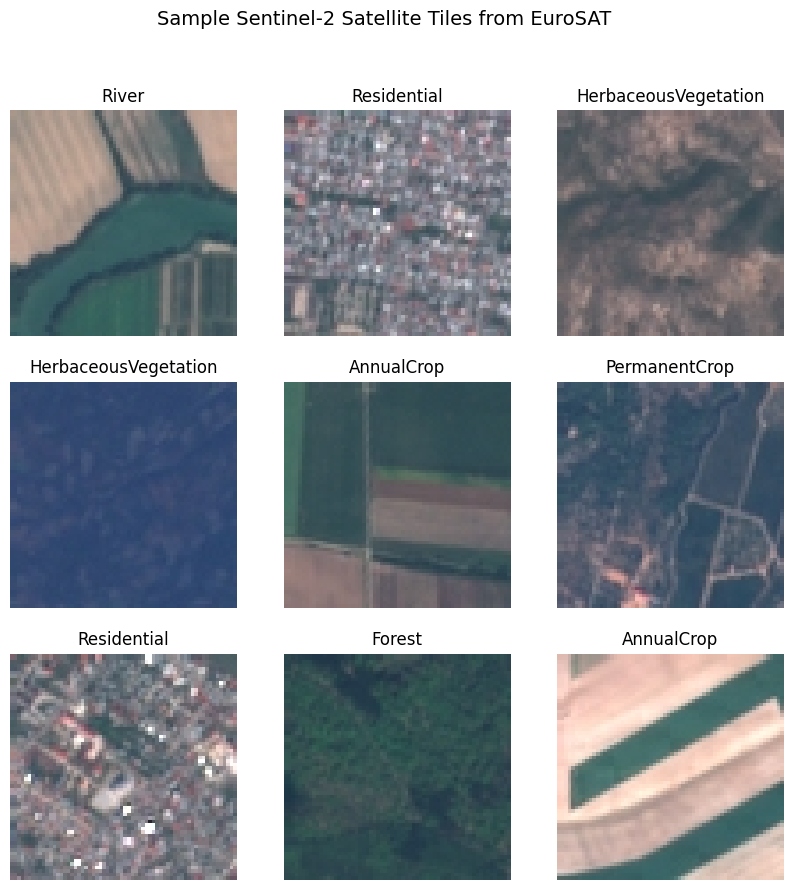

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in ds_train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Sample Sentinel-2 Satellite Tiles from EuroSAT", fontsize=14)
plt.show()

Right now our pixel values range from 0-255 (standard image format). Neural networks train much better when inputs are small numbers — typically 0-1 — because it keeps the math stable during training (large numbers can cause the model to learn unevenly or slowly). This is the image equivalent of feature scaling in your car price project.
We'll add a normalization layer directly into the data pipeline so every image gets rescaled automatically as it's loaded:

In [13]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

ds_train = ds_train.map(lambda x, y: (normalization_layer(x), y))
ds_test = ds_test.map(lambda x, y: (normalization_layer(x), y))

# Quick check: pixel values should now be between 0 and 1
for images, labels in ds_train.take(1):
    print("Min pixel value:", images.numpy().min())
    print("Max pixel value:", images.numpy().max())

Min pixel value: 0.0627451
Max pixel value: 1.0


Before the code: now we build the actual model — a Convolutional Neural Network (CNN). Unlike the LinearRegression you used before (which just weighs input features directly), a CNN scans small patches of the image looking for patterns — edges, textures, shapes — and stacks these patterns into increasingly complex features (e.g., edges → textures → "this looks like a road" → "this looks like Highway"). That's why CNNs work well for images and plain regression doesn't.
We'll keep it simple: a few convolution layers to extract features, then a couple of dense layers to make the final classification decision.

In [14]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 3)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

684,490 trainable parameters, clean architecture, no shape mismatches. Now let's train it.
Quick idea before the code: training means showing the model the training images repeatedly (each full pass through the data is called an epoch), letting it adjust its internal weights to reduce mistakes, and checking its performance on the validation set after each pass — so we can see if it's actually learning or just memorizing.

In [15]:
epochs = 10

history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=epochs
)

Epoch 1/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 171s 250ms/step - accuracy: 0.4859 - loss: 1.3379 - val_accuracy: 0.5619 - val_loss: 1.1648
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 176s 261ms/step - accuracy: 0.6706 - loss: 0.9128 - val_accuracy: 0.6709 - val_loss: 0.8984
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 193s 247ms/step - accuracy: 0.7200 - loss: 0.7804 - val_accuracy: 0.7930 - val_loss: 0.5933
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 176s 261ms/step - accuracy: 0.7493 - loss: 0.6971 - val_accuracy: 0.7546 - val_loss: 0.6801
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 167s 247ms/step - accuracy: 0.7749 - loss: 0.6370 - val_accuracy: 0.8178 - val_loss: 0.5039
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 174s 258ms/step - accuracy: 0.8057 - loss: 0.5548 - val_accuracy: 0.8324 - val_loss: 0.4961
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 205s 263ms/step - accuracy: 0.8220 - loss: 0.5071 - val_accuracy: 0.8431 - val_loss: 0.4484
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 176s 261ms/step - accuracy: 0.8387 -

What is an epoch? An epoch is when a model reviews all its training data (21,600 images) from beginning to end just once. Since you said "epochs=10," the model reviewed these 21,600 images 10 times, learning to predict a little better each time. 675/675 shows how many batches (in groups of 32) were processed within each epoch (21,600 ÷ 32 = 675).
The results are quite good:

Epoch 1: 48% accuracy (slightly better than random prediction, not yet learned)
Epoch 10: 85.7% training accuracy, 85.15% validation accuracy

This is a really good result; training and validation accuracy are close (85.7 vs 85.15), meaning the model isn't memorizing, it's actually learning (there doesn't seem to be any overfitting). In Epoch 9, val_accuracy dropped slightly (0.82) and then recovered (0.85), which is normal, a common fluctuation during training. Now let's visualize this learning process.

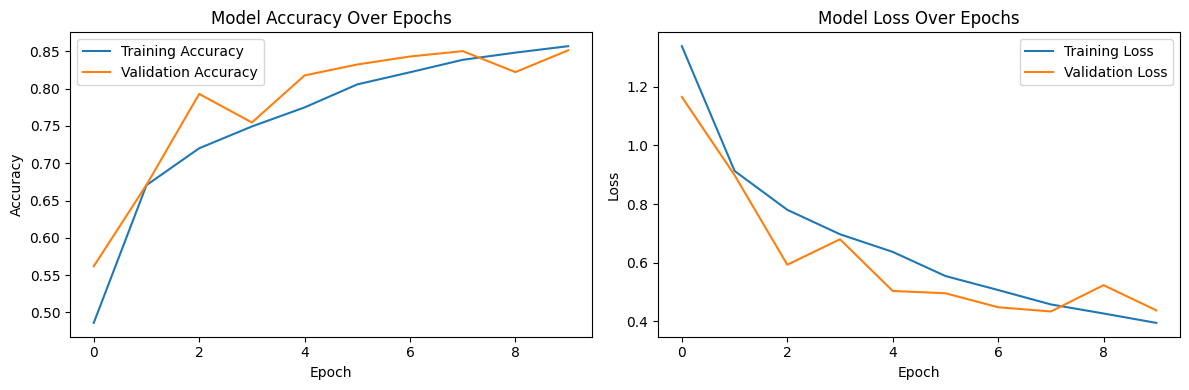

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Both are high and close to each other (our case: 85.7% vs 85.15%) → The model has truly learned and can generalize to new data. This is the ideal situation.
High training, low validation (example: 95% vs 60%) → This means overfitting. The model has memorized the training data but fails with data it has never seen before, meaning it is not useful in the real world. Both are low → Underfitting, the model has not learned enough, more epochs, a more complex architecture, or better data preparation may be needed.

The idea: We'll take the model's predictions from a test set (5,400 images), data the model has never seen before—like evaluating a new plot in the real world. Then we'll assign a random "declared type" to each image, making most of them correct (the same as the actual label), and some intentionally incorrect to simulate "false declarations." Finally, if the model prediction doesn't match the declared type, we'll flag it as "NEEDS REVIEW."

In [17]:
import pandas as pd
import random

random.seed(42)
np.random.seed(42)

# Gerçek etiketleri ve görüntüleri test setinden topla
true_labels = []
images_list = []

for images, labels in ds_test:
    images_list.extend(images.numpy())
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)
images_array = np.array(images_list)

# Model tahminlerini al
predictions = model.predict(images_array)
predicted_labels = np.argmax(predictions, axis=1)
confidence_scores = np.max(predictions, axis=1)

print(f"Toplam test görüntüsü: {len(true_labels)}")
print(f"Model tahmin doğruluğu (kontrol amaçlı): {(predicted_labels == true_labels).mean():.4f}")

169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step
Toplam test görüntüsü: 5400
Model tahmin doğruluğu (kontrol amaçlı): 0.8515


In real life, a farmer's declaration is recorded in a database. Since we don't have such data, we will simulate it: in most plots (around 85%) the declaration will be correct (identical to the actual label), while in the rest we will intentionally assign an incorrect type — that is, we are creating plots with "false declarations". This percentage is a realistic assumption (most farmers declare correctly, a minority are non-compliant).

In [20]:
# Simulate "declared land type" data
fraud_rate = 0.15  # 15% chance the declaration is false (simulation)

declared_labels = []
for true_label in true_labels:
    if random.random() < fraud_rate:
        # False declaration: pick a random class different from the true one
        wrong_choices = [c for c in range(num_classes) if c != true_label]
        declared_labels.append(random.choice(wrong_choices))
    else:
        # Honest declaration
        declared_labels.append(true_label)

declared_labels = np.array(declared_labels)

print(f"Simulated false declaration rate: {(declared_labels != true_labels).mean():.2%}")

Simulated false declaration rate: 15.37%


Now let's build the actual compliance check.
Idea: We compare each parcel's declared type against the model's predicted type (not the true label — in real life, we'd never have the true label, only the model's best guess). If they disagree, we flag it as "REVIEW REQUIRED." We'll also include the model's confidence score, since a low-confidence mismatch might deserve different priority than a high-confidence one.

In [22]:
# Build the compliance screening table
results_df = pd.DataFrame({
    'declared_type': [class_names[i] for i in declared_labels],
    'predicted_type': [class_names[i] for i in predicted_labels],
    'model_confidence': confidence_scores,
    'true_type': [class_names[i] for i in true_labels]  # kept only for our own validation, not used by the "system"
})

results_df['flagged_for_review'] = results_df['declared_type'] != results_df['predicted_type']

print(f"Total parcels screened: {len(results_df)}")
print(f"Flagged for review: {results_df['flagged_for_review'].sum()} ({results_df['flagged_for_review'].mean():.2%})")

results_df.head(10)

Total parcels screened: 5400
Flagged for review: 1496 (27.70%)


,declared_type,predicted_type,model_confidence,true_type,flagged_for_review
0,Residential,Residential,0.992232,Residential,False
1,SeaLake,SeaLake,0.996489,SeaLake,False
2,Highway,Highway,0.828894,Highway,False
3,Forest,Forest,0.997969,Forest,False
4,River,AnnualCrop,0.997147,AnnualCrop,True
5,SeaLake,SeaLake,0.998586,SeaLake,False
6,PermanentCrop,PermanentCrop,0.652566,PermanentCrop,False
7,SeaLake,SeaLake,0.999989,SeaLake,False
8,Residential,Residential,0.996187,Residential,False
9,PermanentCrop,Residential,0.993871,Residential,True


Looks correct — row 4 and row 9 are flagged exactly where declared and predicted disagree, and interestingly both flagged cases in this preview actually match the true_type correctly caught by the model (row 4: true=AnnualCrop, model correctly said AnnualCrop, but declared said River — a real mismatch caught).
Now let's check how good this flagging system actually is. This is the most important part for your portfolio story, because "it flags stuff" isn't enough — we need to show how well it flags the right stuff.
Idea: We check four numbers, borrowed from fraud/anomaly detection evaluation:

True Positives: flagged parcels where the declaration really was false → good catches.
False Positives: flagged parcels where the declaration was actually true → false alarms (wastes inspector time).
False Negatives: false declarations that slipped through unflagged → missed cases (bad, but expected sometimes since the model itself isn't 100% accurate).
True Negatives: correctly left alone.

In [23]:
# Ground truth: was the declaration actually false?
actually_false = (declared_labels != true_labels)
flagged = results_df['flagged_for_review'].values

true_positives = (flagged & actually_false).sum()
false_positives = (flagged & ~actually_false).sum()
false_negatives = (~flagged & actually_false).sum()
true_negatives = (~flagged & ~actually_false).sum()

print(f"True Positives (correctly caught false declarations): {true_positives}")
print(f"False Positives (honest declarations wrongly flagged): {false_positives}")
print(f"False Negatives (false declarations missed): {false_negatives}")
print(f"True Negatives (correctly left alone): {true_negatives}")

precision = true_positives / (true_positives + false_positives)
recall = true_positives / (true_positives + false_negatives)

print(f"\nPrecision (of flagged parcels, % actually fraudulent): {precision:.2%}")
print(f"Recall (of all false declarations, % caught): {recall:.2%}")

True Positives (correctly caught false declarations): 818
False Positives (honest declarations wrongly flagged): 678
False Negatives (false declarations missed): 12
True Negatives (correctly left alone): 3892

Precision (of flagged parcels, % actually fraudulent): 54.68%
Recall (of all false declarations, % caught): 98.55%



Recall: 98.55% — the system catches almost every false declaration. Excellent from a "don't let fraud slip through" perspective.
Precision: 54.68% — but only about half of what gets flagged is actually a real problem. The other half are honest declarations getting flagged unnecessarily.
Why the precision is lower than you might expect: Remember, the model itself is only ~85% accurate. So even for the 85% of parcels with honest declarations, the model itself misclassifies about 15% of them — and that misclassification alone triggers a "mismatch" flag, even though the farmer told the truth. In other words: a chunk of your false positives aren't really compliance failures, they're just the model's own imperfection showing up as noise in the comparison.
This is actually a great insight for your portfolio story — it shows you understand the system isn't just "model accuracy = system accuracy." A real deployment would need a smarter design, for example:

Use confidence score as a filter: maybe only flag a mismatch if the model's confidence is high (e.g., >90%) — low-confidence mismatches are more likely to be the model being unsure, not a real fraud case.
Route flagged cases by confidence tier: high-confidence mismatches → urgent field visit; low-confidence mismatches → lower priority, maybe a second image/pass needed.

Let's quickly test the confidence-filtering idea.

In [24]:
# Check: does filtering by confidence improve precision?
high_conf_flagged = results_df['flagged_for_review'] & (results_df['model_confidence'] > 0.90)

tp_hc = (high_conf_flagged & actually_false).sum()
fp_hc = (high_conf_flagged & ~actually_false).sum()

precision_hc = tp_hc / (tp_hc + fp_hc)
recall_hc = tp_hc / actually_false.sum()

print(f"With confidence > 0.90 filter:")
print(f"Precision: {precision_hc:.2%}")
print(f"Recall: {recall_hc:.2%}")
print(f"Parcels flagged: {high_conf_flagged.sum()} (vs {flagged.sum()} before)")


With confidence > 0.90 filter:
Precision: 90.16%
Recall: 62.89%
Parcels flagged: 579 (vs 1496 before)


What this means in plain terms: By only trusting the model's high-confidence mismatches, 9 out of 10 flagged parcels are now genuinely problematic (vs. roughly 1 out of 2 before) — inspectors waste far less time. But the trade-off is we now only catch ~63% of actual false declarations, missing more real cases than before.
This is exactly the kind of decision a real agency would have to make, and it's a great point to make in your portfolio: there's no single "correct" answer — it depends on whether the priority is catching every case (high recall, use no filter or a low threshold) or not wasting inspector time (high precision, use a high threshold). You could even show this as a tunable "policy knob."
Let's finish with one summary visual — a simple bar chart comparing the two strategies, good as your closing image.

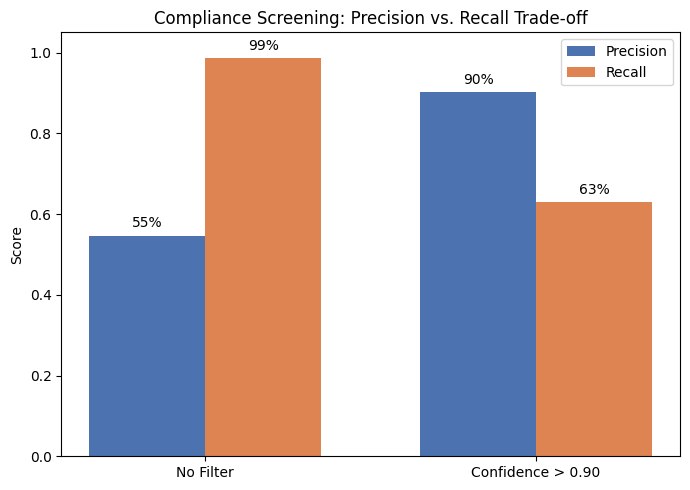

In [25]:
import matplotlib.pyplot as plt

strategies = ['No Filter', 'Confidence > 0.90']
precision_vals = [precision, precision_hc]
recall_vals = [recall, recall_hc]

x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, precision_vals, width, label='Precision', color='#4C72B0')
ax.bar(x + width/2, recall_vals, width, label='Recall', color='#DD8452')

ax.set_ylabel('Score')
ax.set_title('Compliance Screening: Precision vs. Recall Trade-off')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylim(0, 1.05)
ax.legend()

for i, v in enumerate(precision_vals):
    ax.text(i - width/2, v + 0.02, f"{v:.0%}", ha='center')
for i, v in enumerate(recall_vals):
    ax.text(i + width/2, v + 0.02, f"{v:.0%}", ha='center')

plt.tight_layout()
plt.show()